# GAN Lecture Notebook

## Vanilla GAN demo with training visualization.

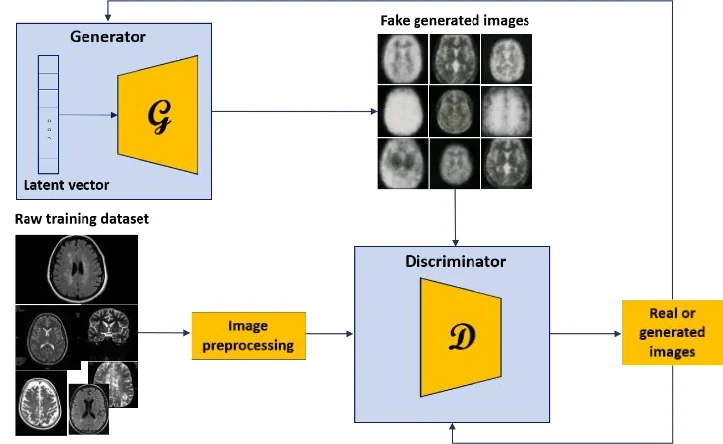

## Imports

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import sys
from torchvision.utils import make_grid
from PIL import Image
import random
from tqdm import tqdm

In [39]:
! pip install torch torchvision matplotlib pillow tqdm

## Dataset Loading

### Load FashionMNIST Dataset

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
loader = DataLoader(dataset, batch_size=128, shuffle=True)
print('Dataset size:', len(dataset))

Dataset size: 60000


### Visualize Dataset Samples

In [6]:
class_names = dataset.classes
train_targets = dataset.targets
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
test_targets = test_dataset.targets

train_counts = torch.bincount(train_targets, minlength=len(class_names))
test_counts = torch.bincount(test_targets, minlength=len(class_names))
total_counts = train_counts + test_counts

sample_image, _ = dataset[0]

print("Dataset overview")
print(f"- Train samples: {len(dataset):,}")
print(f"- Test samples: {len(test_dataset):,}")
print(f"- Number of classes: {len(class_names)}")
print(f"- Image shape: {tuple(sample_image.shape)}")
print(f"- Normalized pixel range: [{sample_image.min().item():.2f}, {sample_image.max().item():.2f}]")


Dataset overview
- Train samples: 60,000
- Test samples: 10,000
- Number of classes: 10
- Image shape: (1, 28, 28)
- Normalized pixel range: [-1.00, 1.00]



Class distribution
 0. T-shirt/top  | train= 6000 | test=1000 | total= 7000
 1. Trouser      | train= 6000 | test=1000 | total= 7000
 2. Pullover     | train= 6000 | test=1000 | total= 7000
 3. Dress        | train= 6000 | test=1000 | total= 7000
 4. Coat         | train= 6000 | test=1000 | total= 7000
 5. Sandal       | train= 6000 | test=1000 | total= 7000
 6. Shirt        | train= 6000 | test=1000 | total= 7000
 7. Sneaker      | train= 6000 | test=1000 | total= 7000
 8. Bag          | train= 6000 | test=1000 | total= 7000
 9. Ankle boot   | train= 6000 | test=1000 | total= 7000


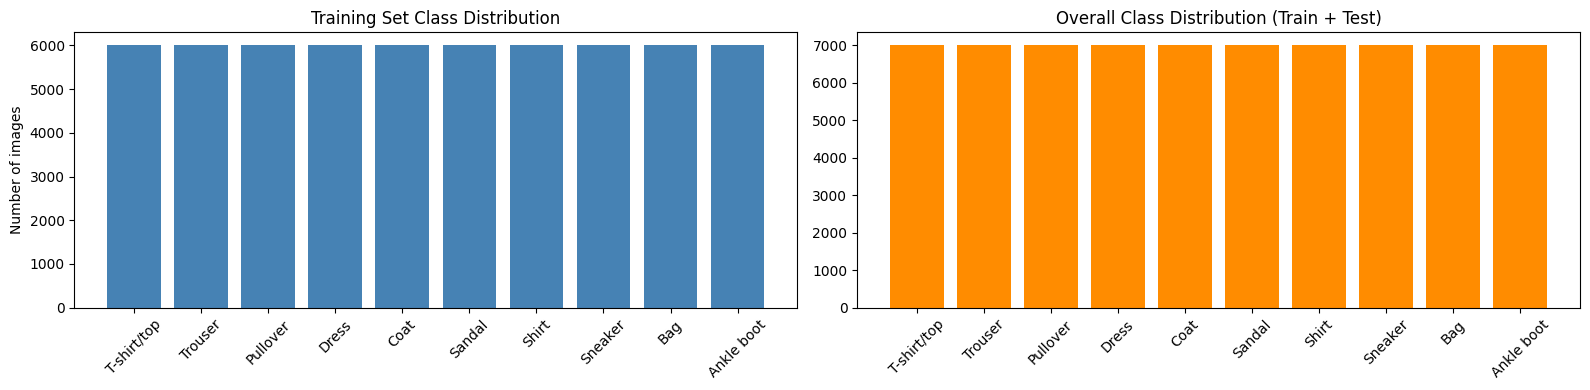

In [7]:
print("\nClass distribution")
for idx, class_name in enumerate(class_names):
    print(
        f"{idx:>2}. {class_name:<12} | train={train_counts[idx].item():>5} | "
        f"test={test_counts[idx].item():>4} | total={total_counts[idx].item():>5}"
    )

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].bar(class_names, train_counts.numpy(), color="steelblue")
axes[0].set_title("Training Set Class Distribution")
axes[0].set_ylabel("Number of images")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(class_names, total_counts.numpy(), color="darkorange")
axes[1].set_title("Overall Class Distribution (Train + Test)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


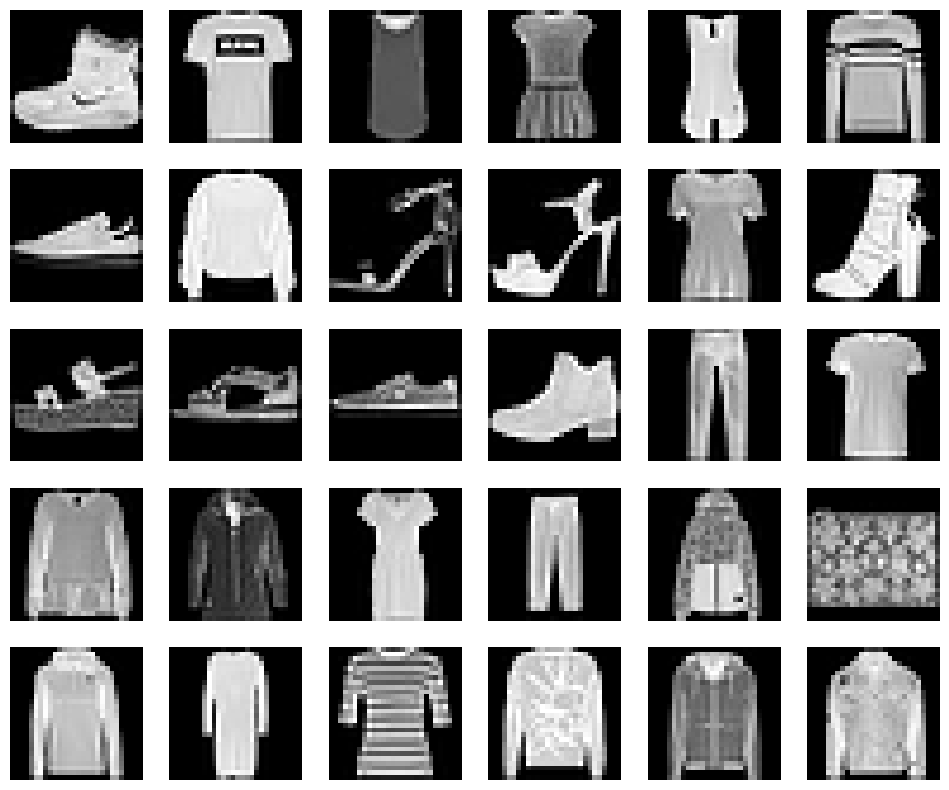

In [16]:
fig, ax = plt.subplots(5,6, figsize=(12,10))
for i in range(30):
    img, label = dataset[i]
    ax[i//6,i%6].imshow(img.squeeze(), cmap='gray')
    ax[i//6,i%6].axis('off')
plt.show()

## GAN Architecture

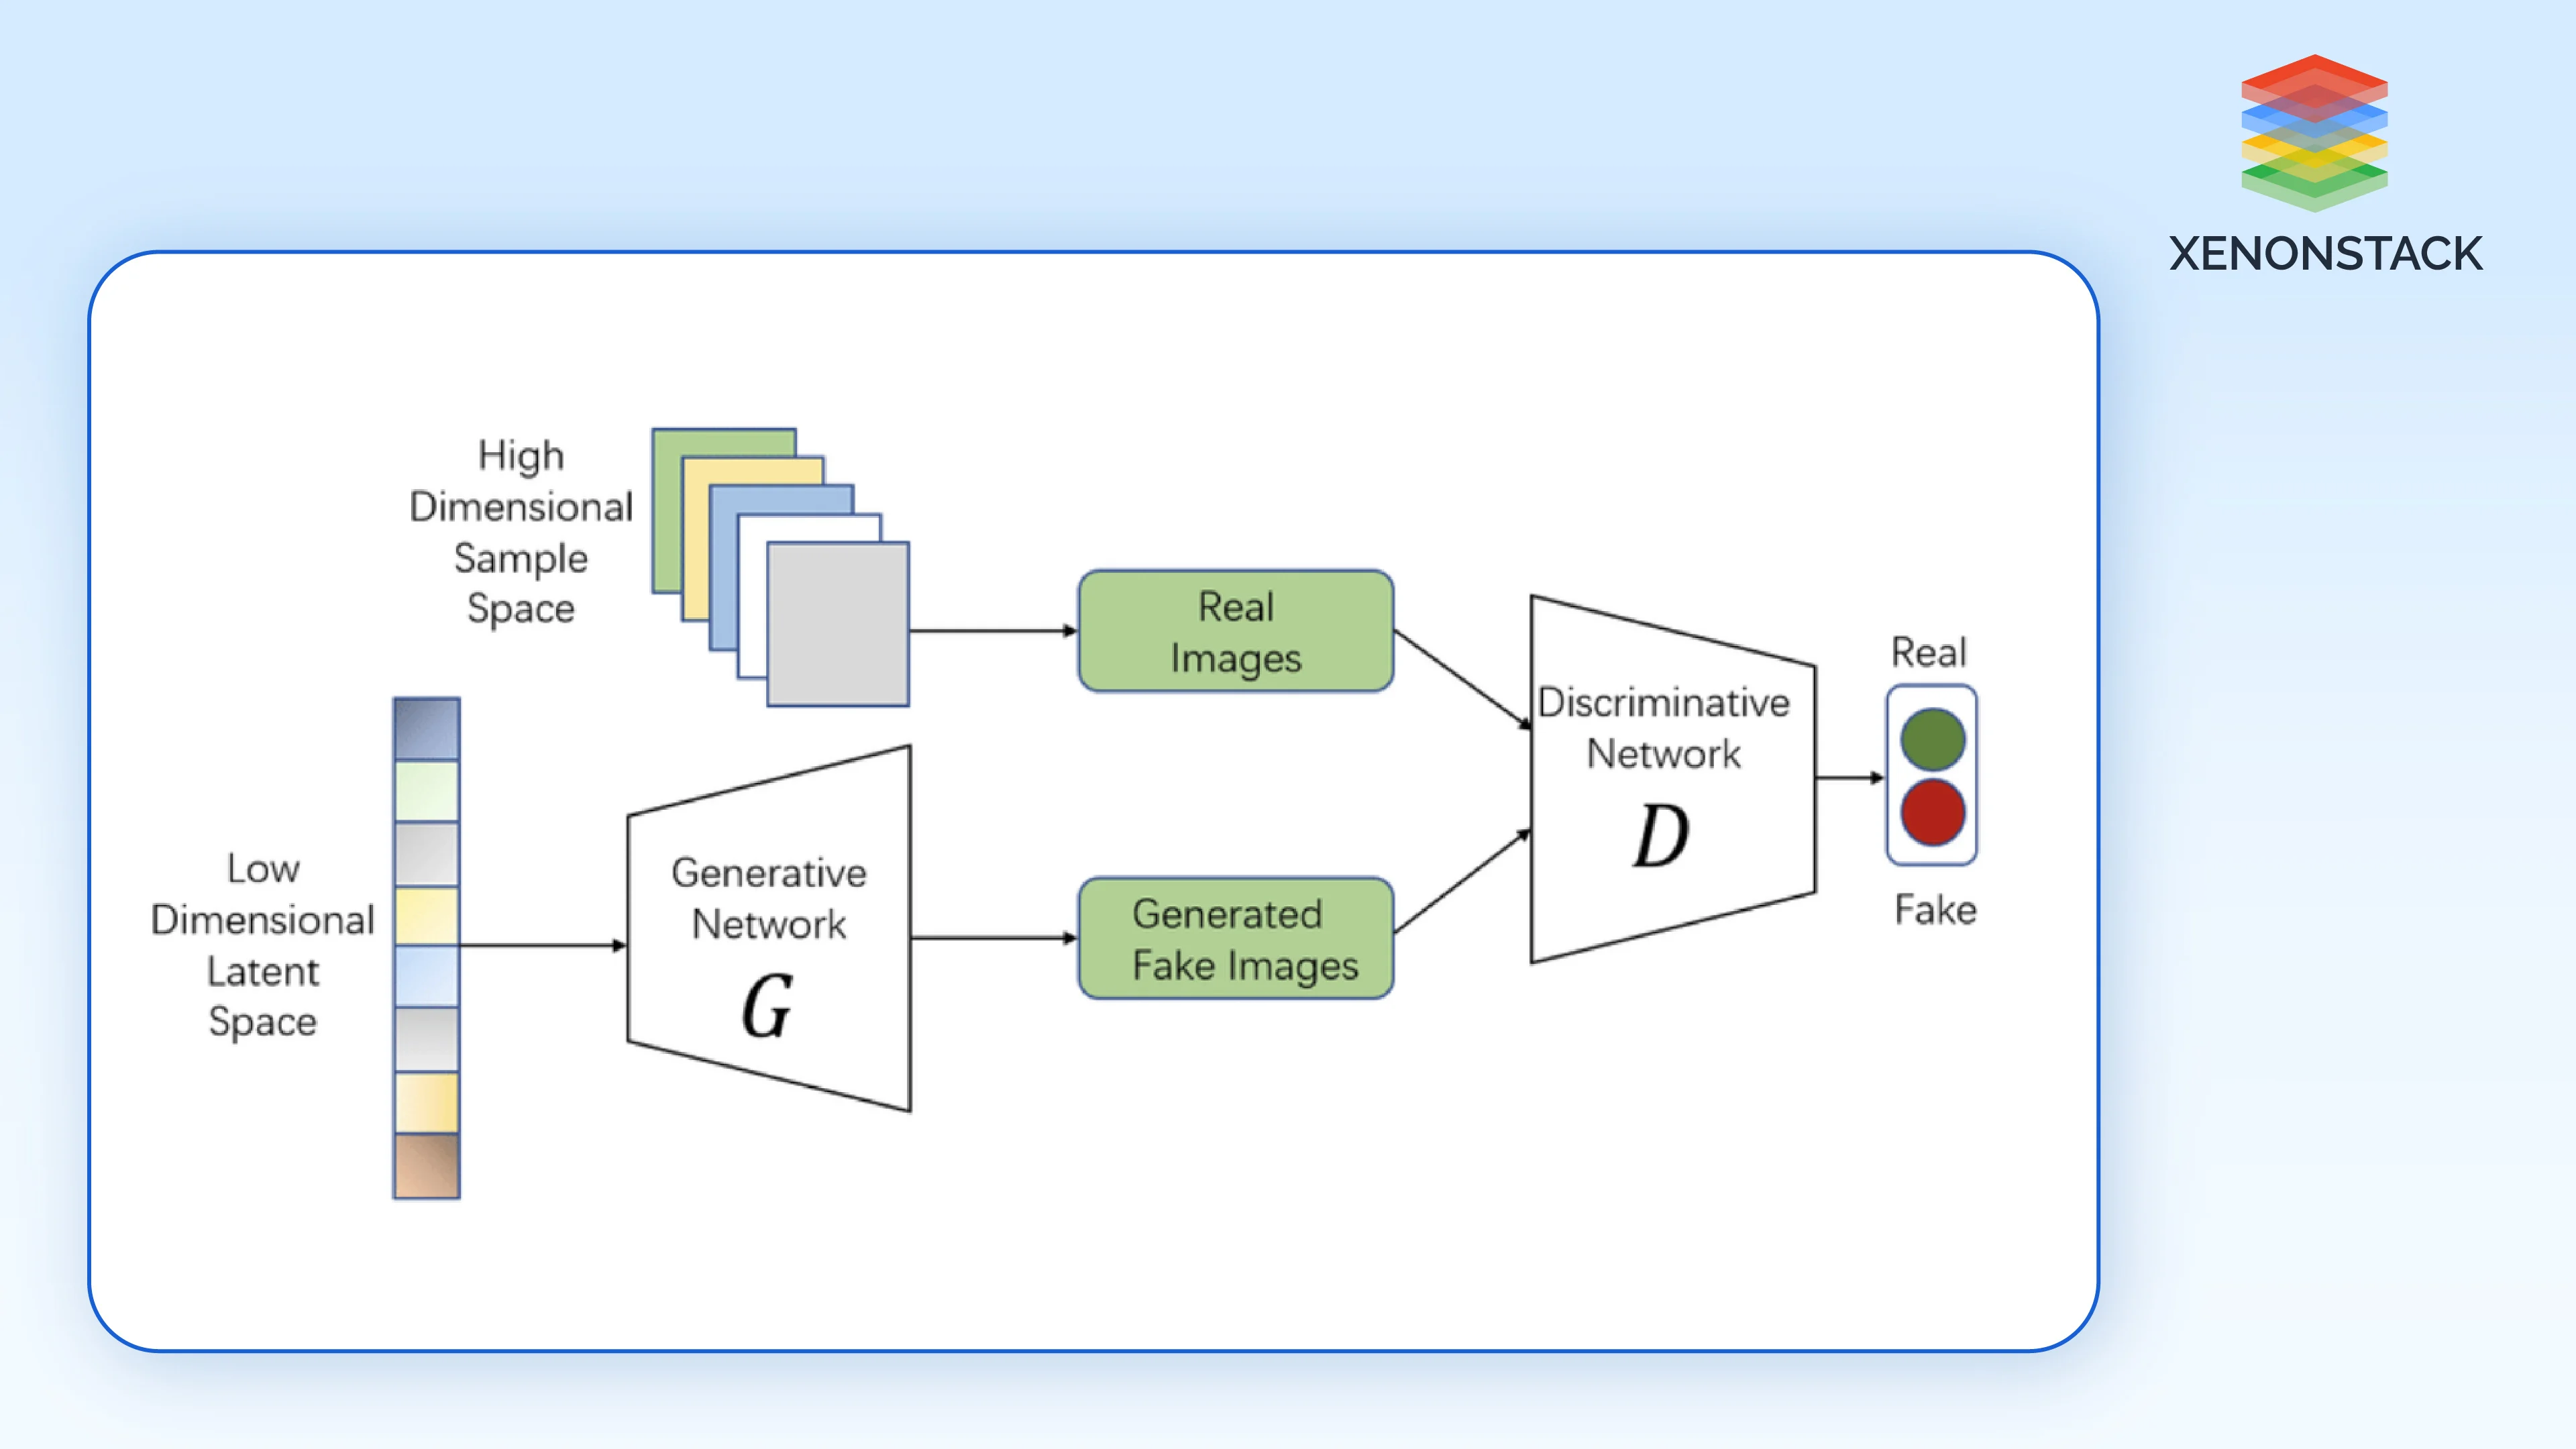

In [18]:
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim,256),
            nn.ReLU(),
            nn.Linear(256,512),
            nn.ReLU(),
            nn.Linear(512,784),
            nn.Tanh()
        )
    def forward(self,x):
        return self.net(x).view(-1,1,28,28)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784,512),
            nn.LeakyReLU(0.2),
            nn.Linear(512,256),
            nn.LeakyReLU(0.2),
            nn.Linear(256,1),
            nn.Sigmoid()
        )
    def forward(self,x):
        return self.net(x)

### Initialize Models

In [19]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
G = Generator().to(device)
D = Discriminator().to(device)
criterion = nn.BCELoss()
g_opt = optim.Adam(G.parameters(), lr=0.0002)
d_opt = optim.Adam(D.parameters(), lr=0.0002)

### Training Loop

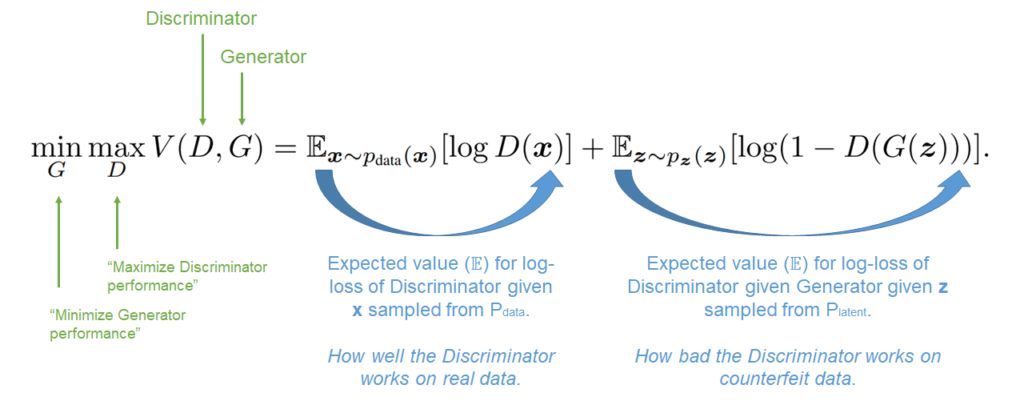

In [20]:
epochs = 25
z_dim = 100
g_losses = []
d_losses = []

for epoch in range(epochs):
    for real,_ in loader:
        real = real.to(device)
        batch = real.size(0)

        real_labels = torch.ones(batch,1).to(device)
        fake_labels = torch.zeros(batch,1).to(device)

        z = torch.randn(batch,z_dim).to(device)
        fake = G(z)

        d_real = D(real)
        d_fake = D(fake.detach())

        loss_real = criterion(d_real, real_labels)
        loss_fake = criterion(d_fake, fake_labels)

        d_loss = loss_real + loss_fake

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        g_fake = D(fake)
        g_loss = criterion(g_fake, real_labels)

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

    print('Epoch', epoch, 'G loss', g_loss.item(), 'D loss', d_loss.item())

Epoch 0 G loss 6.838298320770264 D loss 0.02849629707634449
Epoch 1 G loss 5.231635093688965 D loss 0.045284777879714966
Epoch 2 G loss 5.688931941986084 D loss 0.030209431424736977
Epoch 3 G loss 6.36053466796875 D loss 0.04901769757270813
Epoch 4 G loss 5.752155303955078 D loss 0.28397539258003235
Epoch 5 G loss 5.146002769470215 D loss 0.07054442167282104
Epoch 6 G loss 4.073434829711914 D loss 0.3736661672592163
Epoch 7 G loss 5.043517112731934 D loss 0.1494450867176056
Epoch 8 G loss 4.911707878112793 D loss 0.4555233120918274
Epoch 9 G loss 3.756554365158081 D loss 0.38528329133987427
Epoch 10 G loss 7.296668529510498 D loss 0.1931297481060028
Epoch 11 G loss 4.578546524047852 D loss 0.2921351194381714
Epoch 12 G loss 4.139071941375732 D loss 0.408208966255188
Epoch 13 G loss 5.368306636810303 D loss 0.23929619789123535
Epoch 14 G loss 4.436561107635498 D loss 0.2497430145740509
Epoch 15 G loss 4.164405822753906 D loss 0.23522529006004333
Epoch 16 G loss 3.4446353912353516 D loss

### Training Loss Visualization

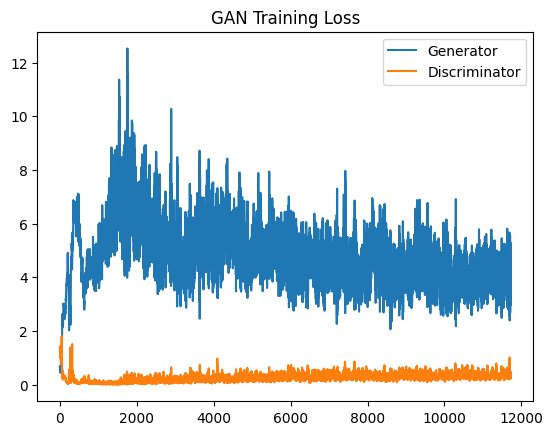

In [21]:
plt.plot(g_losses)
plt.plot(d_losses)
plt.legend(['Generator','Discriminator'])
plt.title('GAN Training Loss')
plt.show()

### Analysis of the Generated Images

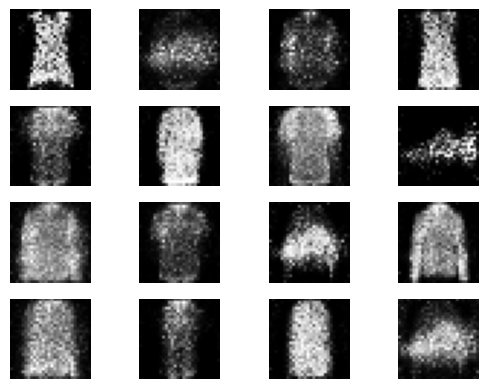

In [22]:
z = torch.randn(16,100).to(device)
fake = G(z).detach().cpu()

fig, ax = plt.subplots(4,4)
for i in range(16):
    ax[i//4,i%4].imshow(fake[i][0], cmap='gray')
    ax[i//4,i%4].axis('off')
plt.show()

### Latent Space Morphing

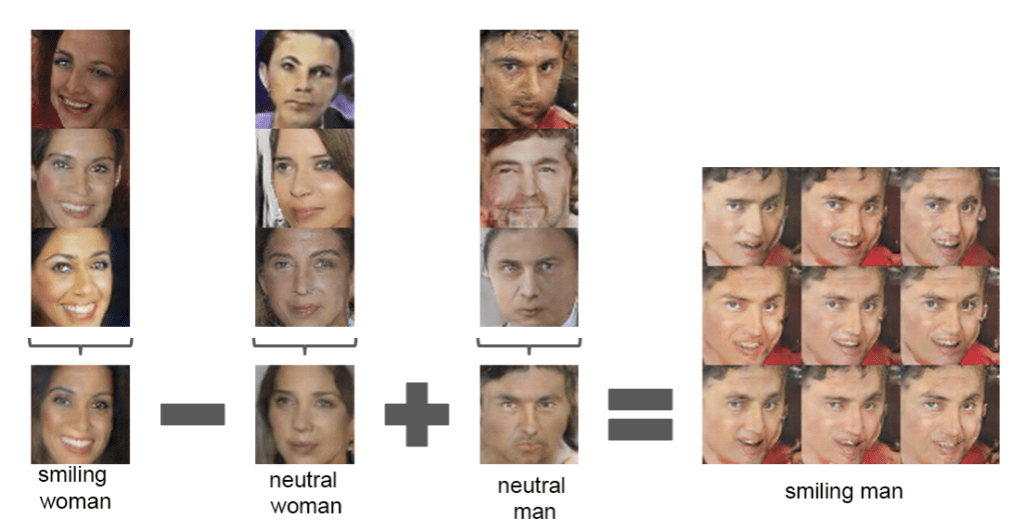

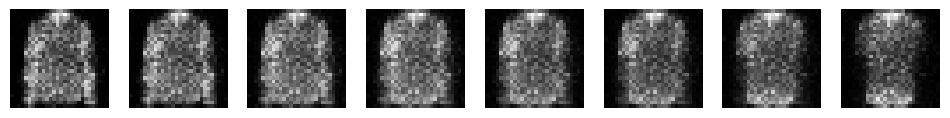

In [24]:
z1 = torch.randn(1,100).to(device)
z2 = torch.randn(1,100).to(device)
alphas = np.linspace(0,1,8)

fig, ax = plt.subplots(1,8, figsize=(12,2))

for i,a in enumerate(alphas):
    z = (1-a)*z1 + a*z2
    img = G(z).detach().cpu()
    ax[i].imshow(img[0][0], cmap='gray')
    ax[i].axis('off')

plt.show()

## StyleGAN Demo

Use pretrained NVIDIA model:

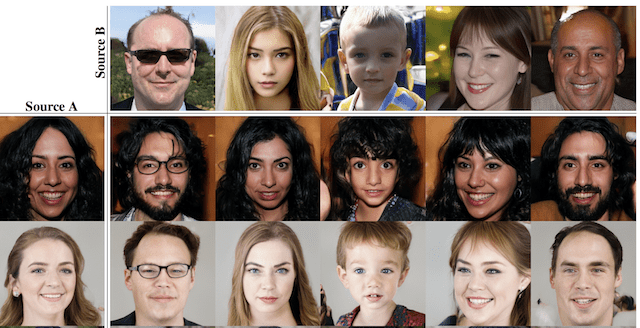

### Install & Load

In [25]:
%%bash
pip install torch torchvision
pip install ninja imageio imageio-ffmpeg
git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git
cd stylegan2-ada-pytorch
# pip install -r requirements.txt

fatal: destination path 'stylegan2-ada-pytorch' already exists and is not an empty directory.


### 

In [28]:
sys.path.append("/home/biswamitra/tt_nil/stylegan2-ada-pytorch")

import legacy
import dnnlib


### Image Morphing (Latent Interpolation)


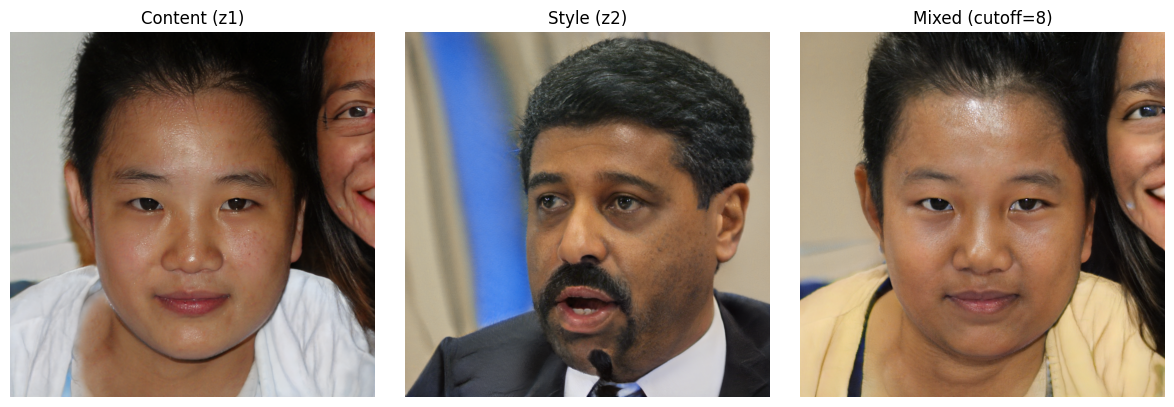

In [34]:
# Load model
with dnnlib.util.open_url("ffhq.pkl") as f:
    G = legacy.load_network_pkl(f)['G_ema'].cuda();

# Generate latents
z1 = torch.randn([1, G.z_dim]).cuda()  # Content
z2 = torch.randn([1, G.z_dim]).cuda()  # Style

# Map to W
w1 = G.mapping(z1, None)
w2 = G.mapping(z2, None)

# Generate individual images
img1 = G.synthesis(w1, noise_mode='const')
img2 = G.synthesis(w2, noise_mode='const')

# Style mixing
w_mix = w1.clone()
cutoff = 8
w_mix[:, cutoff:] = w2[:, cutoff:]

img_mix = G.synthesis(w_mix, noise_mode='const')

# Convert function
def process(img):
    img = (img.clamp(-1, 1) + 1) * 127.5
    img = img.permute(0, 2, 3, 1).cpu().numpy().astype(np.uint8)[0]
    return img

img1 = process(img1)
img2 = process(img2)
img_mix = process(img_mix)

# Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img1)
plt.title("Content (z1)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img2)
plt.title("Style (z2)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_mix)
plt.title(f"Mixed (cutoff={cutoff})")
plt.axis('off')

plt.tight_layout()
from IPython.display import clear_output

clear_output(wait=True)
plt.show()

### Style Translationmn

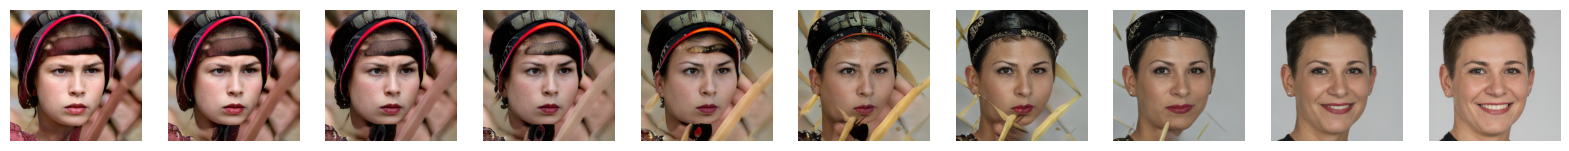

In [35]:
z1 = torch.randn(1, G.z_dim).cuda()
z2 = torch.randn(1, G.z_dim).cuda()

alphas = np.linspace(0, 1, 10)

plt.figure(figsize=(20,4))

for i, alpha in enumerate(alphas):
    z = (1-alpha)*z1 + alpha*z2
    img = G(z, None, truncation_psi=0.7, noise_mode='const')
    
    img = (img.clamp(-1,1)+1)*127.5
    img = img.permute(0,2,3,1).cpu().numpy().astype(np.uint8)[0]
    
    plt.subplot(1,10,i+1)
    plt.imshow(img)
    plt.axis('off')
clear_output(wait=True)
plt.show()

### Some Realistic Image Generation Using the model

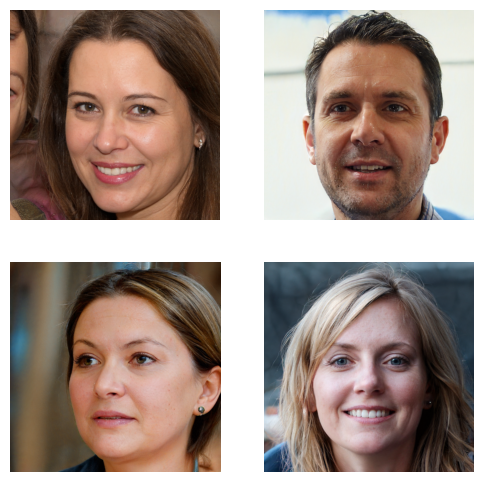

In [37]:
# Load model
network_pkl = "https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with dnnlib.util.open_url(network_pkl) as f:
    G = legacy.load_network_pkl(f)['G_ema'].to(device)

# Generate images
z = torch.randn(4, G.z_dim).to(device)
c = None

img = G(z, c, truncation_psi=0.7, noise_mode='const')

# Convert to image
img = (img.clamp(-1,1)+1)*127.5
img = img.permute(0,2,3,1).cpu().numpy().astype(np.uint8)

# Show
plt.figure(figsize=(6,6))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(img[i])
    plt.axis('off')
clear_output(wait=True)
plt.show()

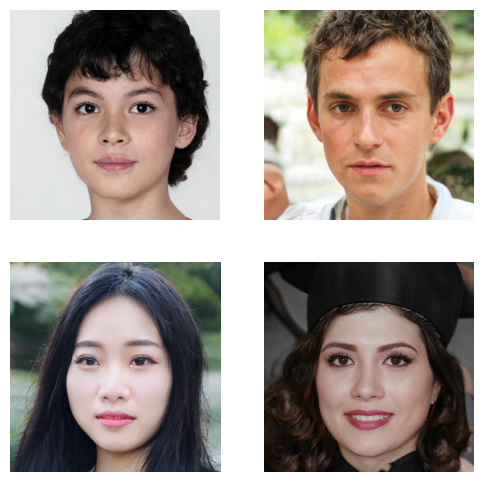

In [38]:
# Load pretrained model
network_pkl = "https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with dnnlib.util.open_url(network_pkl) as f:
    G = legacy.load_network_pkl(f)['G_ema'].to(device)

# Generate images
z = torch.randn(4, G.z_dim).to(device)

img = G(z, None, truncation_psi=0.7, noise_mode='const')

# Convert to display
img = (img.clamp(-1,1)+1)*127.5
img = img.permute(0,2,3,1).cpu().numpy().astype(np.uint8)

# Show results
plt.figure(figsize=(6,6))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(img[i])
    plt.axis('off')
clear_output(wait=True)
plt.show()

## Image Impainting

In [40]:
import torchvision.transforms as transforms

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

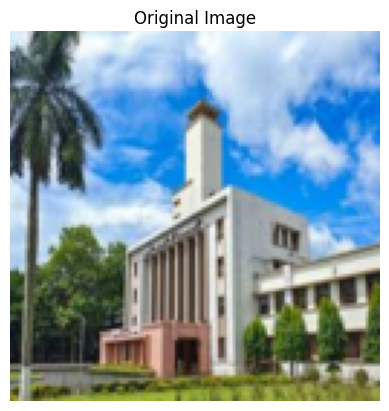

In [43]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    return transform(img).unsqueeze(0)

img = load_image("sample.jpg")  # replace with your image
plt.imshow(img.squeeze().permute(1,2,0))
plt.title("Original Image")
plt.axis("off")

### Model Set up

In [44]:
class InpaintNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.ReLU()
        )

        # Decoder
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.enc(x)
        x = self.dec(x)
        return x

model = InpaintNet().cuda()

In [45]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [56]:
import random
import torch

def random_mask(img, mask_size=30):
    _, _, h, w = img.shape
    mask = torch.ones_like(img)

    x = random.randint(0, w - mask_size)
    y = random.randint(0, h - mask_size)

    mask[:, :, y:y+mask_size, x:x+mask_size] = 0
    return mask

In [63]:
epochs = 500

img = img.cuda()

mask = random_mask(img.cpu()).cuda()
masked_img = img * mask

for epoch in range(epochs):
    optimizer.zero_grad()

    output = model(masked_img)

    # Only compute loss in missing region
    loss = criterion(output * (1 - mask), img * (1 - mask))

    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.0070
Epoch 50, Loss: 0.0000
Epoch 100, Loss: 0.0000
Epoch 150, Loss: 0.0000
Epoch 200, Loss: 0.0000
Epoch 250, Loss: 0.0000
Epoch 300, Loss: 0.0000
Epoch 350, Loss: 0.0000
Epoch 400, Loss: 0.0000
Epoch 450, Loss: 0.0000


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

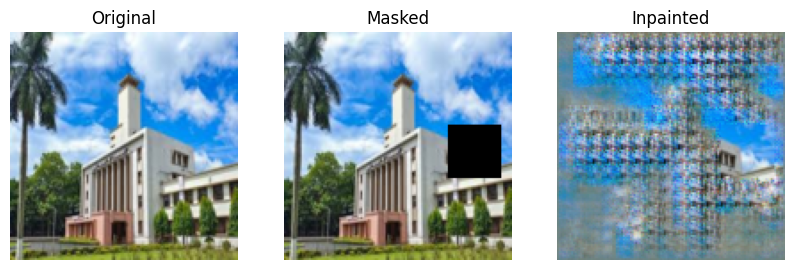

In [64]:
output = model(masked_img).detach().cpu()

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(img.cpu().squeeze().permute(1,2,0))
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(masked_img.cpu().squeeze().permute(1,2,0))
plt.title("Masked")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(output.squeeze().permute(1,2,0))
plt.title("Inpainted")
plt.axis("off")